# Thread Pools and Thread Lifecycle
- Threads pools and understanding the thread lifecycle are crucial concepts for effective concurrent progamming. They enable developers to create scalable applications that efficiently utilize system resouces while maintaining control over thread creation and management.
## Thread lifecycle
### State Diragram
- 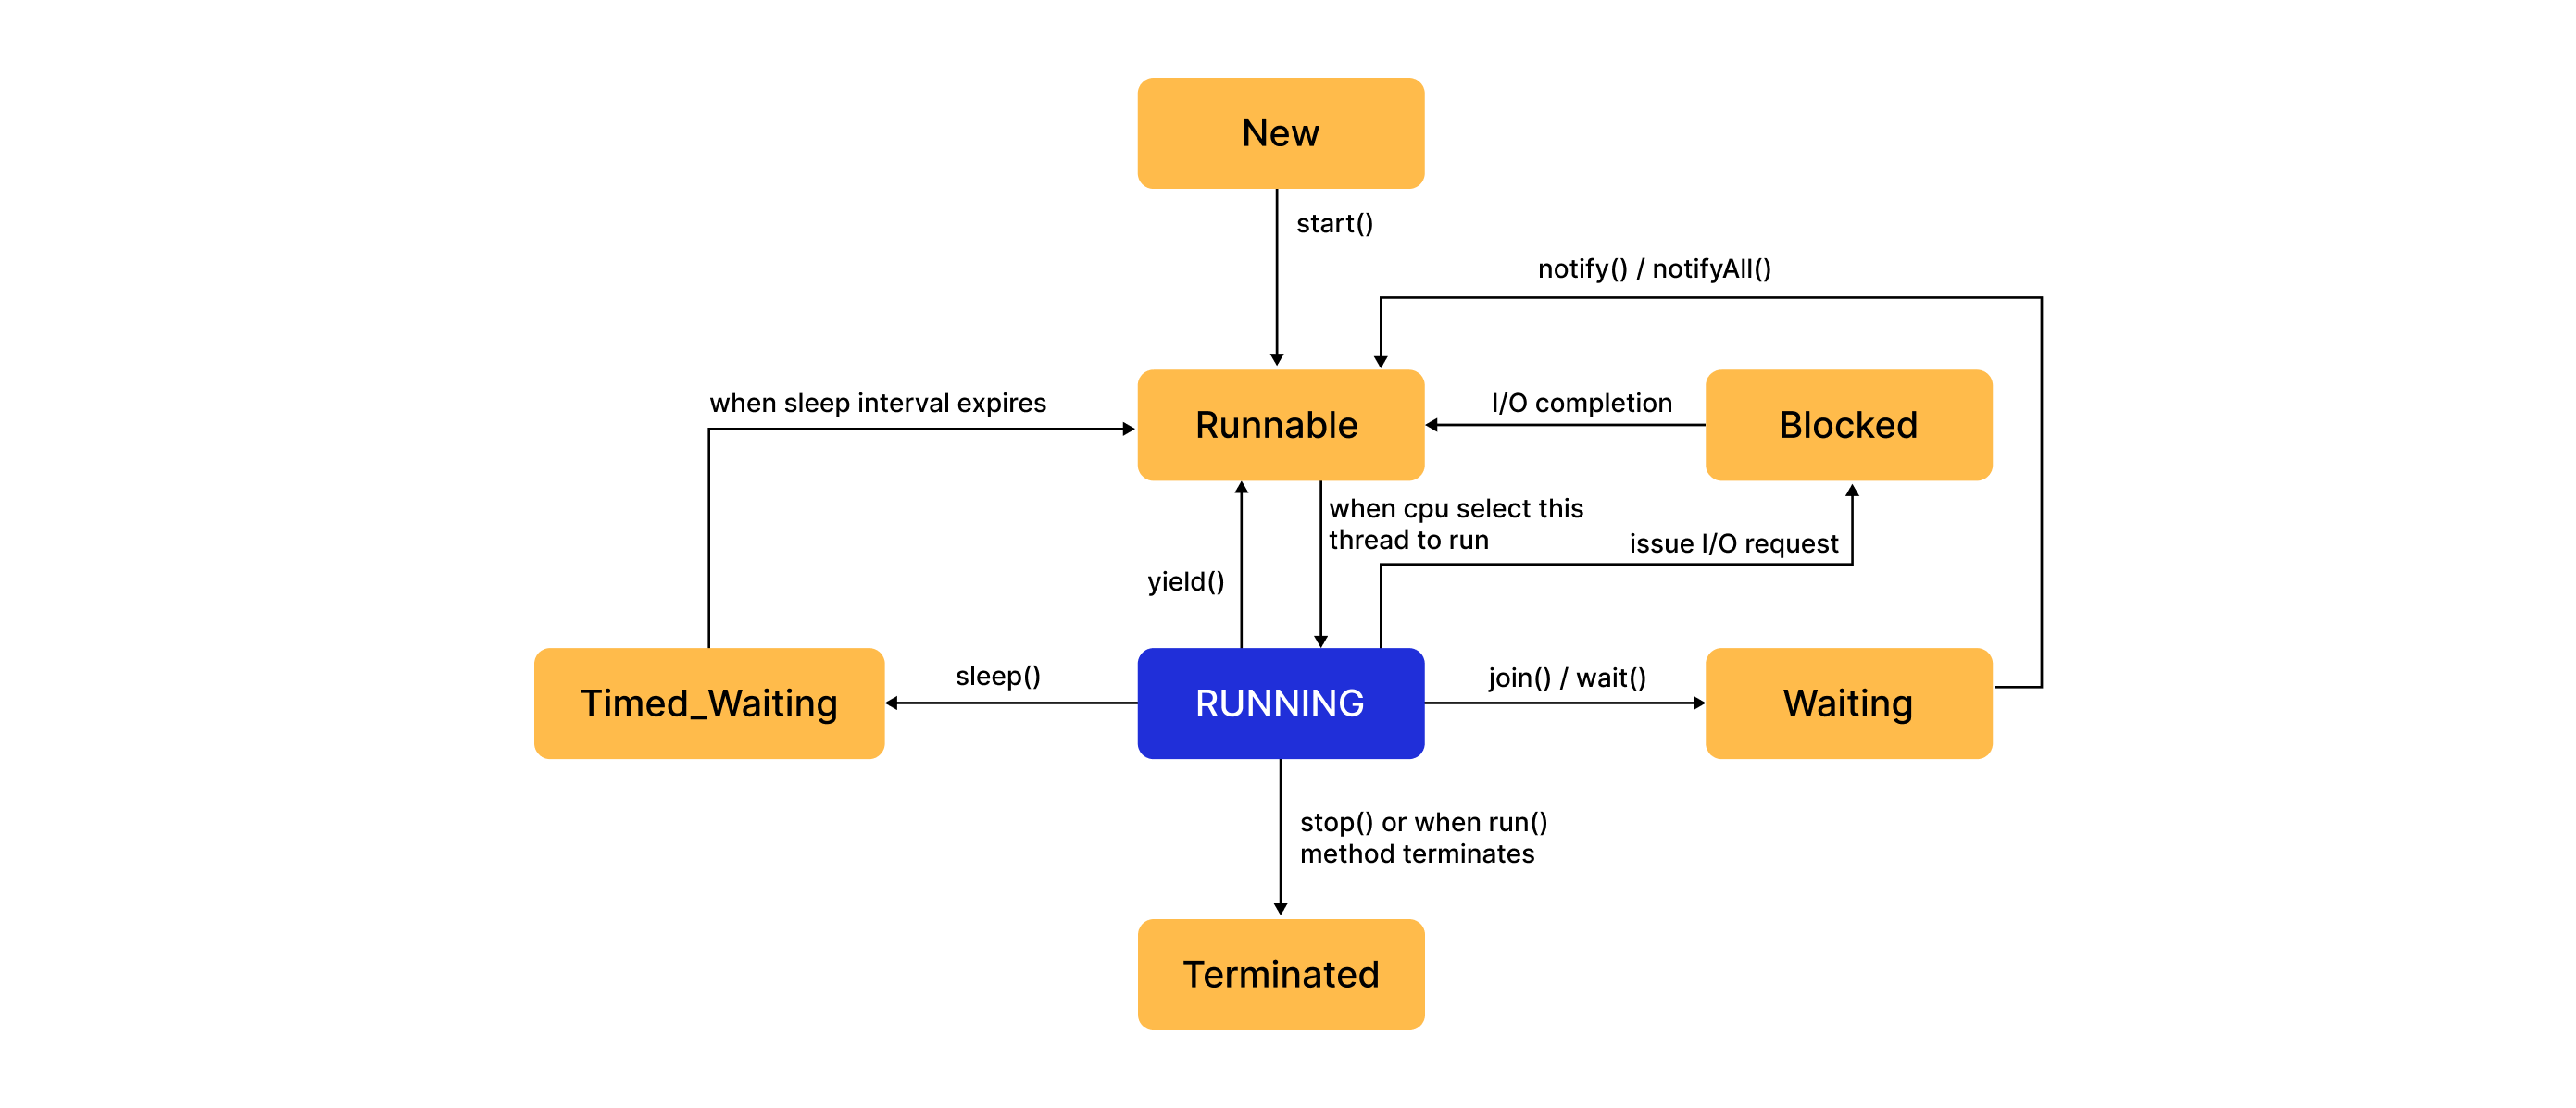

In [2]:
import threading

thread = threading.Thread(target = lambda: print("Hello from thread"))
# Thread is created but NOT started yet

#### 2. RUNNABLE
- Thread is ready for execution and waiting for CPU allocation
- Once start() is called, thread moves to this state.
- Includes ready-to-run state

In [3]:
import threading

thread = threading.Thread(target = lambda: print("Hello from thread"))
# thread.start()  Thread moves to the RUNNABLE state

#### 3. RUNNING
- The thread is currently executing its task on the CPU.
- The CPU scheduler has allocated processing time to this thread.

In [4]:
# When the CPU scheduler picks a RUNNABLE thread, it enters the RUNNING state
import threading

class RunningExample(threading.Thread):
    def run(self):
        print("Thread is now RUNNING.")

def main():
    thread = RunningExample()
    thread.start() # Moves to RUNNABLE, then eventually RUNNING

main()

Thread is now RUNNING.


#### 4. BLOCKED
- Thread is temporarily inactive while waiting to acquire a lock
- Typically occurs when trying to enter a synchronized block/method already locked by another thread.

In [5]:
import threading
lock = threading.Lock()

with lock:
    # If another thread holds the lock,
    # this thread will BLOCK until the lock is availale
    pass

#### 5. WAITING
- Thread is waiting indefinitely for another thread to perform a specific action
- Entered via methods like Object.wait(), Thread.join(), or LockSupport.park()
- No timeout specified

In [ ]:
import threading

condition = threading.Condition()

with condition:
    try:
        condition.wait()  # Releases lock and waits
    except Exception:
        pass

In [1]:
import threading
import time

condition = threading.Condition()

def waiting_thread():
    with condition:
        print("Thread is entering WAIT state...")
        condition.wait()
        print("Thread resumed after notify")

def notifying_thread():
    time.sleep(2)
    with condition:
        print("Notifying waiting thread...")
        condition.notify()

t1 = threading.Thread(target=waiting_thread)
t2 = threading.Thread(target=notifying_thread)

t1.start()
t2.start()


Thread is entering WAIT state...
Notifying waiting thread...
Thread resumed after notify


### Simulation How another Thread wakes the waiting Thread:
#### Scebario: Restaurant order processing
- Thread A (Waiter) taks the customer's order and waits for the chef to prepare the food.
- Thread B (Chef) preprares the food and notifies the waiter when it's ready.

In [3]:
import threading
import time

# Thread A (Waiter - Enters WAITING State)
class WaiterThread(threading.Thread):
    def __init__(self, condition):
        super().__init__()
        self.condition = condition

    def run(self):
        with self.condition:
            print("Waiter: Waiting for the food to be ready...")
            self.condition.wait()
            print("Waiter: Food is ready! Delivering to the customer.")

# Thread B (Chef- Notifies the Waiter)
class ChefThread(threading.Thread):
    def __init__(self, condition):
        super().__init__()
        self.condition = condition

    def run(self):
        time.sleep(2)
        with self.condition:
            print("Chef: Food is ready! Notifying the waiter.")
            self.condition.notify() # Wake up the waiter

class ResturantSimulation:
    @staticmethod
    def main():
        condition = threading.Condition()

        waiter = WaiterThread(condition)
        chef = ChefThread(condition)

        waiter.start()
        chef.start()

        waiter.join()
        chef.join()

ResturantSimulation.main()



Waiter: Waiting for the food to be ready...
Chef: Food is ready! Notifying the waiter.
Waiter: Food is ready! Delivering to the customer.


- A thread enters the WAITING state when it is indefinitely waiting for another thread to perform a specific action before it can proceed.
##### Entered via methods like
- Objet.wait()
- Thread.join()
- LockSupport.park()
- No timeout is specified, meaning the thread will remain stuck indefinitely unless another thread wakes it up using the notify() or notifyAll()

#### 6. TIMED WAITING
- thread is waiting for a specific period of time.
- entered via methods like Thread.sleep(timeout), Object.wait(timeout), etc
- Will automatically return to RUNNABLE after timeout expires or notification


In [5]:
import time
import threading

class MyThread(threading.Thread):
    def run(self):
        print("Thread going to sleep...")
        try:
            time.sleep(1)  # TIMED_WAITING
        except Exception as e:
            print("Interrupted:", e)
        print("Thread woke up")

t = MyThread()
t.start()


Thread going to sleep...
Thread woke up


#### 7. TERMINATED
- Thread has completed it execution or was stopped.
- The run() method has exited, either normally or due to an exception
- Thread object still exists but cannot be restarted.
- After thread's run() method completes Thread is in TERIMINATED state.

### Thread Pool 
- Thread pools are a managed collection of reusable threads designed to execute tasks concurrently. They offer significant advantages in resource management, performance, and application stability. 

In [7]:
import time
from concurrent.futures import ThreadPoolExecutor
import threading

def worker_thread(task_id):
    print(f"{threading.current_thread().name} is processing task: {task_id}")
    try:
        time.sleep(2)  # Simulate work
    except Exception as e:
        print("Task interrupted:", e)
    print(f"{threading.current_thread().name} finished task: {task_id}")

if __name__ == "__main__":
    # Create a fixed thread pool with 3 threads
    with ThreadPoolExecutor(max_workers=3) as executor:
        
        # Submit 5 tasks
        for i in range(1, 6):
            executor.submit(worker_thread, i)

    # Executor automatically shuts down when exiting the 'with' block


ThreadPoolExecutor-0_0 is processing task: 1
ThreadPoolExecutor-0_1 is processing task: 2
ThreadPoolExecutor-0_2 is processing task: 3
ThreadPoolExecutor-0_0 finished task: 1
ThreadPoolExecutor-0_0 is processing task: 4
ThreadPoolExecutor-0_2 finished task: 3
ThreadPoolExecutor-0_2 is processing task: 5
ThreadPoolExecutor-0_1 finished task: 2
ThreadPoolExecutor-0_0 finished task: 4
ThreadPoolExecutor-0_2 finished task: 5


In [9]:
import time
from concurrent.futures import ThreadPoolExecutor
import threading


class WorkerThread:
    def __init__(self, taskId):
        self.taskId = taskId

    def run(self):
        threadName = threading.current_thread().name
        print(f"{threadName} is processing taks: {self.taskId}")
        try:
            time.sleep(2)
        except Exception as e:
            print(f"Task interrupted: {e}")
        print(f"{threadName} finished task: {self.taskId}")

class ThreadPoolExample:
    def __init__(self, poolSize=3):
        self.poolSize = poolSize

    def executeTasks(self):
         # Create a fixed thread pool
        with ThreadPoolExecutor(max_workers=self.poolSize) as executor:
            # Submit 7 tasks 
            for i in range(7):
                worker = WorkerThread(i)
                executor.submit(worker.run)

example = ThreadPoolExample(poolSize=3)
example.executeTasks()

ThreadPoolExecutor-2_0 is processing taks: 0
ThreadPoolExecutor-2_1 is processing taks: 1
ThreadPoolExecutor-2_2 is processing taks: 2
ThreadPoolExecutor-2_0 finished task: 0
ThreadPoolExecutor-2_0 is processing taks: 3
ThreadPoolExecutor-2_1 finished task: 1
ThreadPoolExecutor-2_1 is processing taks: 4
ThreadPoolExecutor-2_2 finished task: 2
ThreadPoolExecutor-2_2 is processing taks: 5
ThreadPoolExecutor-2_0 finished task: 3
ThreadPoolExecutor-2_0 is processing taks: 6
ThreadPoolExecutor-2_1 finished task: 4
ThreadPoolExecutor-2_2 finished task: 5
ThreadPoolExecutor-2_0 finished task: 6


- Explanation
    1. Thread Pool Creation
        - Executors.newFixedThreadPool(3) creates a pool with 3 reusable threads.
    2. Task submission
        - 7 tasks are submitted. Since only 3 threads exist, the 1st 3 tasks start immediately.
        - As tasks complete, the available threads pick up the remaining tasks.
    3. Efficient thread usage
        - Threads are reused, avoiding the overhead of creating new threads for each task
        - The execution order may vary based on CPU scheduling.
#### Benefits of Thread Pools
- Resource Management: Limit the number of threads to prevent system overload
- Performance improvement: Reuse existing threads instead of creating new ones.
- Predictability: Control thread creation and scheduling for better application behavior
- Task management: Queuing, scheduling, and monitoring tasks becomes streamlined.

### Combining Thread Lifecycle and Pools
1. Pool Creation:
    - When a thread pool is created, it may pre-create some threads (core threads) in the NEW state and immediately start them to RUNNABLE.
2. Task Execution: When as task is submitted
    - An idle thread in the pool executes the task
    - The thread's state changes according to task operations (RUNNABLE, RUNNING, BLOCKED, WAITING, etc)
    - After task completion, the thread returns to the pool (RUNNABLE state waiting for next task)
3. Pool Shutdown: During shutdown, threads complete their current tasks and are eventually terminated

In [15]:
import time
import threading
from concurrent.futures import ThreadPoolExecutor, wait, ALL_COMPLETED

class Task:
    def __init__(self, task_id):
        self.task_id = task_id
        self.lock = threading.Condition()

    def run(self):
        thread_name = threading.current_thread().name
        print(f"{thread_name} - STARTING Task {self.task_id}")

        try:
            # Simulate RUNNABLE → TIMED_WAITING
            time.sleep(2)

            # Simulate WAITING using Condition
            with self.lock:
                print(f"{thread_name} - WAITING on Task {self.task_id}")
                # WAITING state simulated using wait(timeout)
                self.lock.wait(timeout=1)

            # Back to RUNNABLE → RUNNING
            print(f"{thread_name} - Task {self.task_id} COMPLETED")

        except Exception as e:
            print(f"{thread_name} - Interrupted: {e}")

class ThreadPoolLifecycleDemo:
    def __init__(self):
        self.pool = ThreadPoolExecutor(max_workers=3)

    def execute(self):
        print("Thread Pool Created 🏊‍♂️")

        futures = []
        for i in range(1, 8):
            task = Task(i)
            # Submit the run() method
            futures.append(self.pool.submit(task.run))

        print("Thread Pool Shutdown Initiated 🚦")
        self.pool.shutdown(wait=False)

        # Similar to executor.awaitTermination()
        try:
            done, not_done = wait(futures, timeout=10, return_when=ALL_COMPLETED)
            if not_done:
                print("Forcing Shutdown! 🚧")
                # Python has no shutdownNow() equivalent, so we cancel remaining tasks
                for f in not_done:
                    f.cancel()
        except Exception:
            for f in futures:
                f.cancel()

        print("All Threads Terminated ✅")


if __name__ == "__main__":
    demo = ThreadPoolLifecycleDemo()
    demo.execute()


Thread Pool Created 🏊‍♂️
ThreadPoolExecutor-8_0 - STARTING Task 1
ThreadPoolExecutor-8_1 - STARTING Task 2
ThreadPoolExecutor-8_2 - STARTING Task 3
Thread Pool Shutdown Initiated 🚦
ThreadPoolExecutor-8_0 - WAITING on Task 1
ThreadPoolExecutor-8_2 - WAITING on Task 3
ThreadPoolExecutor-8_1 - WAITING on Task 2
ThreadPoolExecutor-8_2 - Task 3 COMPLETED
ThreadPoolExecutor-8_2 - STARTING Task 4
ThreadPoolExecutor-8_0 - Task 1 COMPLETED
ThreadPoolExecutor-8_0 - STARTING Task 5
ThreadPoolExecutor-8_1 - Task 2 COMPLETED
ThreadPoolExecutor-8_1 - STARTING Task 6
ThreadPoolExecutor-8_2 - WAITING on Task 4
ThreadPoolExecutor-8_1 - WAITING on Task 6
ThreadPoolExecutor-8_0 - WAITING on Task 5
ThreadPoolExecutor-8_1 - Task 6 COMPLETED
ThreadPoolExecutor-8_1 - STARTING Task 7
ThreadPoolExecutor-8_2 - Task 4 COMPLETED
ThreadPoolExecutor-8_0 - Task 5 COMPLETED
ThreadPoolExecutor-8_1 - WAITING on Task 7
ThreadPoolExecutor-8_1 - Task 7 COMPLETED
All Threads Terminated ✅
